# Milk Quality Prediction

We will use machine learning to predict the quality of milk based on its chemical properties.

## Dataset 
The dataset contains the following columns:
- **pH**: The acidity or alkalinity of the milk (Numeric).
- **Temperature**: The temperature of the milk in degrees Celsius (Numeric).
- **Taste**: The taste of the milk (Scaled, Bad/Good).
- **Odor**: The smell of the milk (Scaled,  Bad/Good).
- **Fat**: The fat content of the milk (Scaled, Low/High).
- **Turbidity**: The cloudiness or haziness of the milk (Scaled, Low/High).
- **Colour**: The color of the milk (numeric).
- **Grade**: The overall quality grade of the milk (Categorical, Bad/Moderate/Good).

`Grade` will be our target variable, and the other columns will be used as features for prediction.

>The dataset has been sourced from [Kaggle](https://www.kaggle.com/code/cpluzshrijayan/milk-quality-prediction/input), special thanks to **cpluzshrijayan** for providing the dataset.

In [127]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay,RocCurveDisplay

In [128]:
raw_data= pd.read_csv('milk.csv')
raw_data.head()

,pH,Temperature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,6.6,35,1,0,1,0,254,high
1,6.6,36,0,1,0,1,253,high
2,8.5,70,1,1,1,1,246,low
3,9.5,34,1,1,0,1,255,low
4,6.6,37,0,0,0,0,255,medium


### Label and features definition

In [129]:
label_mapping = {"high":2,"medium":1,"low":0}
map_with_values = False
display_colors = ["blue","green","red"]
display_labels = label_mapping.values() if map_with_values == True else label_mapping.keys()
data = pd.DataFrame(raw_data).assign(grade_categorical=raw_data.Grade.map(label_mapping))
data = data.drop('Grade',axis=1)
data.columns = data.columns.str.lower()
label = 'grade_categorical'
features = data.columns.drop(label).to_list()
features

['ph', 'temperature', 'taste', 'odor', 'fat ', 'turbidity', 'colour']

### Data Analysis

In [130]:
data.describe()

,ph,temperature,taste,odor,fat,turbidity,colour,grade_categorical
count,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000
mean,6.630123,44.226629,0.546742,0.432483,0.671388,0.491029,251.840415,0.836638
std,1.399679,10.098364,0.498046,0.495655,0.469930,0.500156,4.307424,0.787868
min,3.000000,34.000000,0.000000,0.000000,0.000000,0.000000,240.000000,0.000000
25%,6.500000,38.000000,0.000000,0.000000,0.000000,0.000000,250.000000,0.000000
50%,6.700000,41.000000,1.000000,0.000000,1.000000,0.000000,255.000000,1.000000
75%,6.800000,45.000000,1.000000,1.000000,1.000000,1.000000,255.000000,1.000000
max,9.500000,90.000000,1.000000,1.000000,1.000000,1.000000,255.000000,2.000000


#### Correlation Analysis

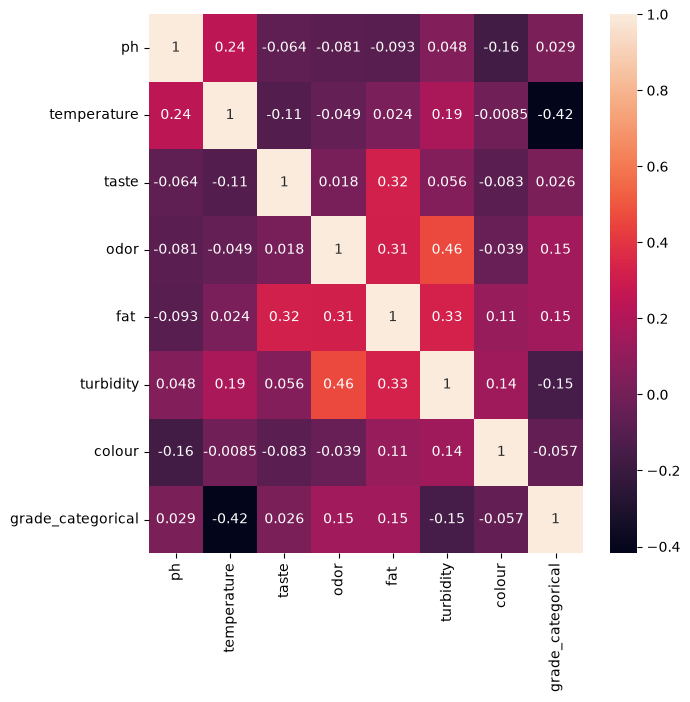

In [131]:
corr = data.corr(numeric_only=True) 
plt.figure(figsize = (7,7))
sns.heatmap(corr, annot=True)
plt.show()

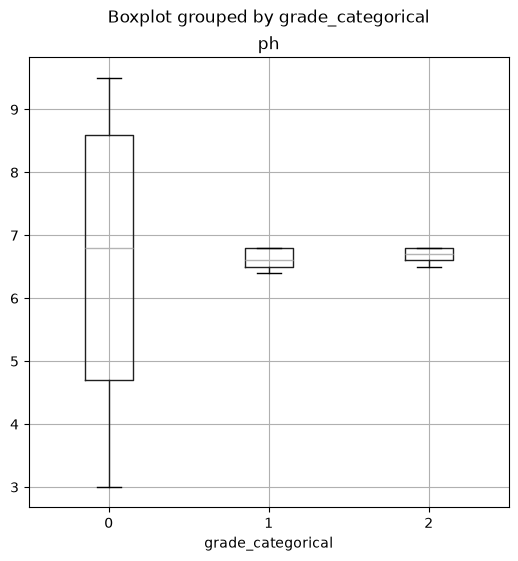

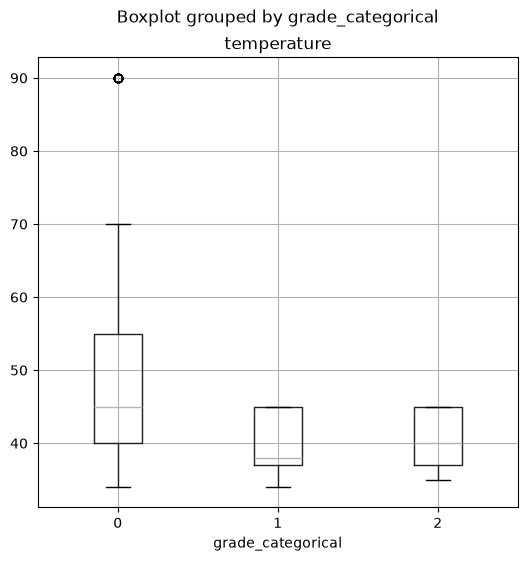

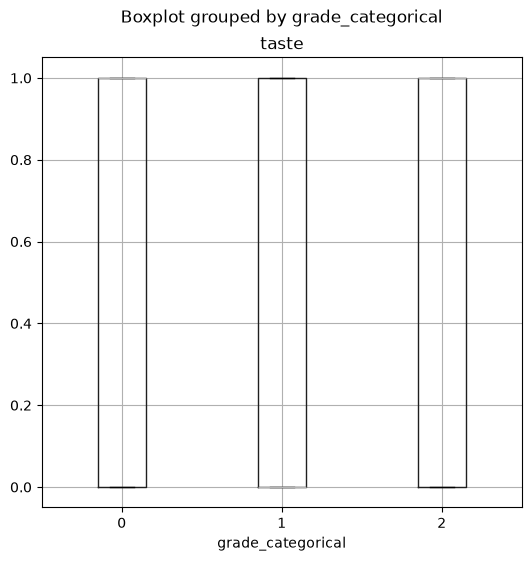

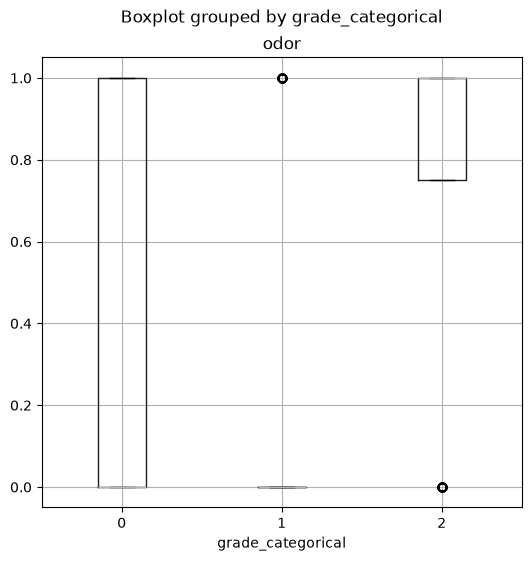

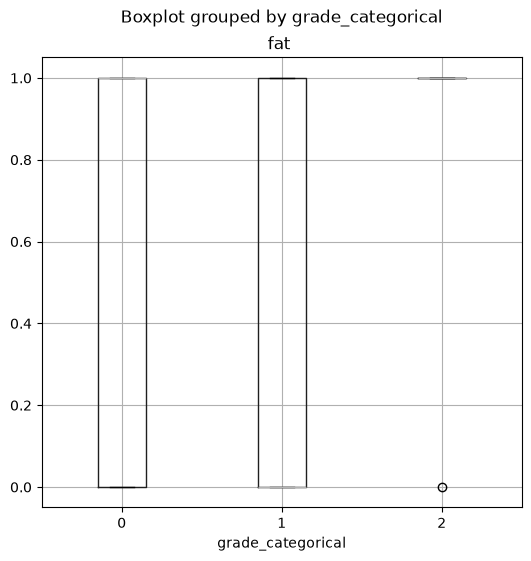

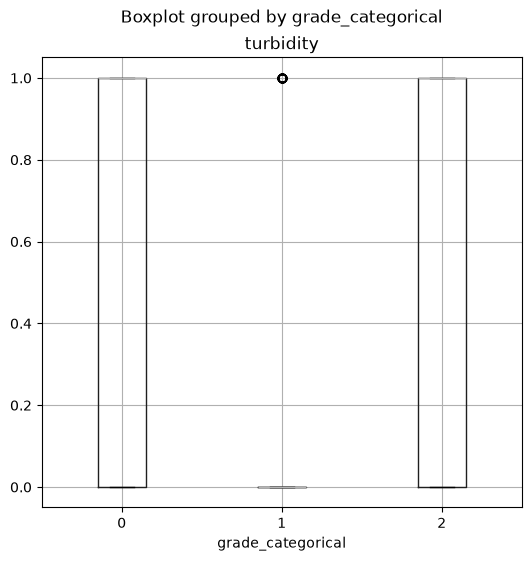

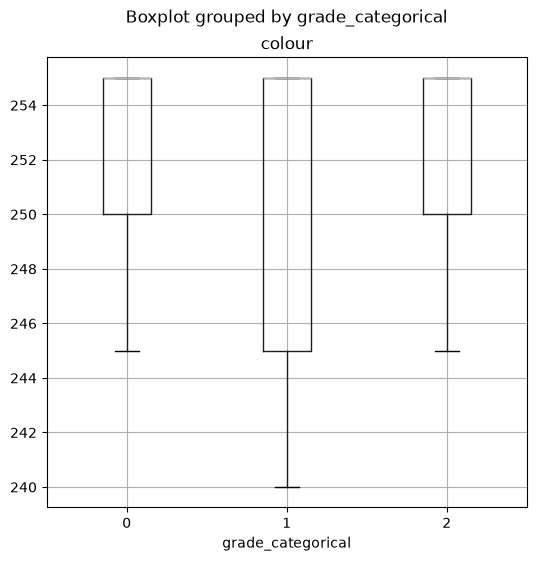

In [132]:
for col in features:
    data.boxplot(column=col, by=label, figsize=(6, 6))
    plt.title(col)
plt.show()

There is no strong correlation between the features, so we will use all of them for our model.

## Data wrangling

In [133]:
data.dtypes

ph                   float64
temperature            int64
taste                  int64
odor                   int64
fat                    int64
turbidity              int64
colour                 int64
grade_categorical      int64
dtype: object

### Scaling and one-hot encoding preprocessor

In [134]:
numeric_features = [
    features.index(x)
    for x in data.loc[
        :,
        ((data.dtypes == "float64") | (data.dtypes == "int64"))
        & (data.max() != 1)
        & (data.min() != 0),
    ].columns.to_list()
]
numeric_features

[0, 1, 6]

In [135]:
categorical_features = [
    features.index(x) for x in data.loc[:, (data.dtypes == "str")].columns.to_list()
]
categorical_features

[]

In [136]:
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

### Train/Test Split

In [137]:
test_size = 0.3
data_x, data_y = data[features], data[label]
x_train, x_test, y_train, y_test = train_test_split(
    data_x, data_y, test_size=test_size, random_state=0, stratify=data_y
)

## Training and testing

### Logistic Regression

In [138]:
regularization_rate = 0.01
c = 1 / regularization_rate
solver = "lbfgs"
predicting_algorithm = LogisticRegression(C=c, solver=solver)

In [139]:
pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("logregressor", predicting_algorithm)]
)
model = pipeline.fit(x_train, (y_train))
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('logregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['ph','temperature','taste',...,'fat ','turbidity','colour']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all rema

#### Statistical Summary

In [140]:
predictions = model.predict(x_test)
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.76      0.71      0.73       129
           1       0.49      0.86      0.63       112
           2       0.67      0.03      0.05        77

    accuracy                           0.59       318
   macro avg       0.64      0.53      0.47       318
weighted avg       0.64      0.59      0.53       318



#### Confusion Matrix

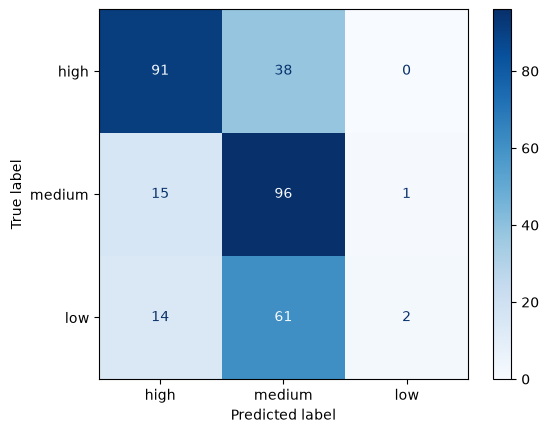

In [141]:
confusion_matrix_result =  confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(
  confusion_matrix=confusion_matrix_result, 
  display_labels=display_labels
)
disp.plot(
  values_format='',
  cmap=plt.cm.Blues
)
plt.show()

#### ROC Curve

In [142]:
y_scores = model.predict_proba(x_test)

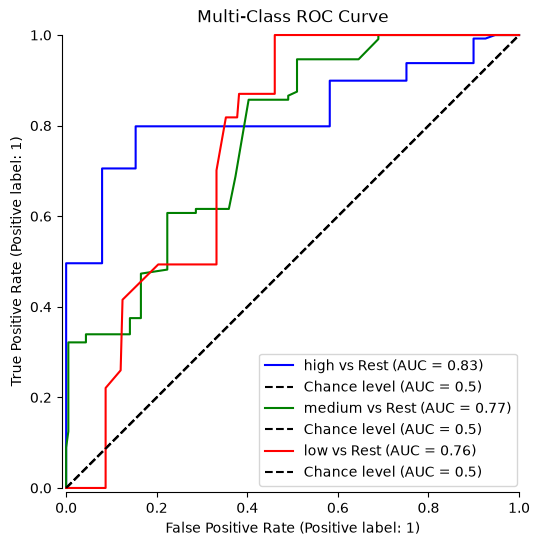

In [146]:
fig, ax = plt.subplots(figsize=(6, 6))
for k,v in enumerate(display_labels):
  disp = RocCurveDisplay.from_predictions(
    y_test == k,
    y_scores[:,k],
    curve_kwargs=dict(color=display_colors[k]),
    plot_chance_level=True,
    despine=True,
    ax=ax,
    name=f"{v} vs Rest"
  )
plt.title("Multi-Class ROC Curve")
plt.show()